# Regressão Linear
Vamos aplicar os conceitos de regressão linear no dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing)

In [12]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.linalg as la

import sys
from pathlib import Path

root = Path().resolve().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from losses import MeanSquaredError, SumSquaredError

mse = MeanSquaredError()
sse = SumSquaredError()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device found: {device}")

features, labels = fetch_california_housing(return_X_y=True)

features = torch.tensor(features, dtype=torch.float32).to(device)
labels = torch.tensor(labels, dtype=torch.float32).view(-1, 1).to(device)

X_train, X_test, t_train, t_test = train_test_split(
    features, labels, test_size=0.25, random_state=SEED
)

Device found: cuda


Definindo a função de perca:
$$
    L(\theta) = \|X \theta - t\|_2^2
$$

Agora vamos implementar as solução de Mínimos Quadrados Ordinários (OLS). Ele acha uma solução exata, mas pode ser muito custoso para datasets muito grandes

In [13]:
I = torch.eye(X_train.shape[1]).to(device)
ols_theta = la.solve(X_train.T @ X_train, I) @ X_train.T @ t_train

In [14]:
y_train = X_train @ ols_theta
print(
    "Erro nos dados de treinamento (OLS):",
    mse.forward(y_train, t_train).item()
)

Erro nos dados de treinamento (OLS): 0.6018795371055603


In [15]:
y_test = X_test @ ols_theta
print(
    "Erro nos dados de teste (OLS):",
    mse.forward(y_test, t_test).item()
)

Erro nos dados de teste (OLS): 0.6159272193908691


Sabendo que o gradiente da LOSS pode ser escrito como:
$$
    L(\theta) = (X \theta - t)^T (X \theta - t)    \\

    = \theta^T X^T X \theta - 2 \theta^T X^T t + t^T t      \\

    \Rightarrow \nabla L(\theta) = 2 X^T (X \theta - t)
$$
podemos aplicar uma regressão linear usando SGD

## Por que usar Gradiente Médio?

A derivada da loss $L(\theta) = \|X \theta - t\|_2^2$ é $\nabla L(\theta) = 2 X^T (X \theta - t)$.

Quando otimizamos em **lotes (minibatches)**, temos dois problemas com o gradiente de soma:

1. **Escala inconsistente**: um lote de tamanho 64 gera um gradiente 64x maior que um lote de tamanho 1, tornando a taxa de aprendizado sensível ao tamanho do lote.
2. **Instabilidade numérica**: gradientes grandes podem causar overflow, especialmente em problemas com muitas amostras.

A solução é usar o **gradiente médio**:

$$
\nabla L_{\text{batch}}(\theta) = \frac{2}{m} X_{\text{batch}}^T (X_{\text{batch}} \theta - t_{\text{batch}})
$$

Isso torna a otimização estável e **independente do tamanho do lote**, permitindo usar taxas de aprendizado mais altas e previsíveis.

In [16]:
# Normalizando os dados com estatísticas do conjunto de treino
feature_mean = X_train.mean(dim=0, keepdim=True)
feature_std = X_train.std(dim=0, unbiased=False, keepdim=True).clamp_min(1e-8)

X_test = (X_test - feature_mean) / feature_std
X_train = (X_train - feature_mean) / feature_std

In [17]:
# Hiperparâmetros do SGD
batch_size = 256  # Lote menor = updates mais frequentes por época
learning_rate = 5e-4  # Taxa intermediária (5x maior que 1e-4, mas 20x menor que 1e-2)
epochs = 1000  # Muito mais épocas para permitir convergência suave
max_norm = None  # Clipping de gradiente (não estamos usando aqui)

# Inicializar theta em zero (mais estável que inicializar aleatoriamente)
theta_sgd = torch.zeros(X_train.shape[1], 1, device=device)

errors = []

print("Treinando SGD com gradiente médio...")
print(f"Taxa de aprendizado: {learning_rate}")
print(f"Tamanho do lote: {batch_size}")
print(f"Épocas: {epochs}\n")

for epoch in range(epochs):
    # Iterar sobre todos os minibatches da época
    for start in range(0, X_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = X_train[start:end]
        t_batch = t_train[start:end]
        
        # ========== PASSO CRÍTICO: GRADIENTE MÉDIO ==========
        # Fórmula da loss: L(θ) = ∑(X @ θ - t)²
        # Gradiente da loss (soma): ∇L(θ) = 2 X^T (X @ θ - t)
        # Gradiente MÉDIO: (1/m) ∇L(θ) onde m = tamanho do lote
        # Isso mantém a escala constante independente do tamanho do lote
        
        residual = X_batch @ theta_sgd - t_batch  # Erro: (m, 1)
        gradient_sum = 2 * X_batch.T @ residual    # Gradiente de soma: (d, 1)
        gradient = gradient_sum / X_batch.shape[0]  # Gradiente médio: (d, 1)
        # ===================================================
        
        # Aplicar clipping do gradiente (desativado, mas deixamos o código)
        if max_norm is not None:
            gradient_norm = torch.norm(gradient)
            if gradient_norm > max_norm:
                gradient = (gradient / gradient_norm) * max_norm
        
        # Atualizar parâmetros na direção oposta ao gradiente
        theta_sgd -= learning_rate * gradient
    
    # Avaliar a loss em TODO o conjunto de treino após cada época
    y_train = X_train @ theta_sgd
    error = sse.forward(y_train, t_train).item()
    
    # Proteger contra NaN (se o algoritmo divergir, paramos)
    if torch.isfinite(torch.tensor(error)):
        errors.append(error)
        if (epoch + 1) % 500 == 0:
            print(f"  Época {epoch + 1:4d}/{epochs}: Loss = {error:.6f}")
    else:
        print(f"  ⚠️  Loss = NaN na época {epoch + 1}. Treinamento interrompido.")
        break

print("Treinamento concluído!")
if len(errors) > 0:
    print(f"Loss inicial: {errors[0]:.6f}")
    print(f"Loss final: {errors[-1]:.6f}")
    print(f"Redução: {100 * (errors[0] - errors[-1]) / errors[0]:.2f}%")


Treinando SGD com gradiente médio...
Taxa de aprendizado: 0.0005
Tamanho do lote: 256
Épocas: 1000

  Época  500/1000: Loss = 74433.953125
  Época 1000/1000: Loss = 74411.593750
Treinamento concluído!
Loss inicial: 85731.898438
Loss final: 74411.593750
Redução: 13.20%


In [18]:
y_train = X_train @ theta_sgd
print(
    "Erro nos dados de treinamento (SGD):",
    mse.forward(y_train, t_train).item()
)

Erro nos dados de treinamento (SGD): 4.806950092315674


In [19]:
y_test = X_test @ theta_sgd
print(
    "Erro nos dados de teste (SGD):",
    mse.forward(y_test, t_test).item()
)

Erro nos dados de teste (SGD): 4.832718849182129


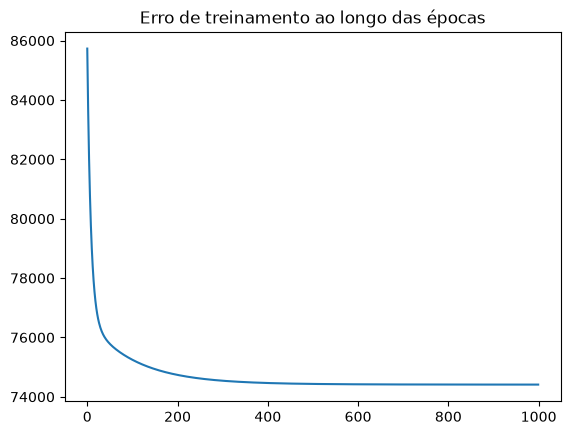

In [20]:
plt.title("Erro de treinamento ao longo das épocas")
plt.plot(range(len(errors)), errors)
plt.show()